# Naive Bayes TF BOW Binary Dimensions
This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer  # <--- The key difference!
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

 --- STEP 1: Load Data  ---


In [20]:
print(" Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])

 Loading data...


 --- STEP 2: Vectorization (Bag of Words) ---

In [21]:
print(" Vectorizing text using Bag of Words (CountVectorizer)...")

# We use CountVectorizer instead of TfidfVectorizer
# max_features=5000 ensures we keep the model size comparable to the paper
vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['posts'])
y = df['type'].values

print(f" Data Ready! Features shape: {X.shape}")

 Vectorizing text using Bag of Words (CountVectorizer)...
 Data Ready! Features shape: (8462, 5000)


--- STEP 3: Train & Evaluate  ---



 Starting Naive Bayes (BoW) with Grid Search Tuning

--- Tuning I vs E (BoW) ---
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best F1-Score: 0.6143
Best Params: {'classifier__alpha': 0.01, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[4922 1612]
 [ 485 1443]]

--- Tuning N vs S (BoW) ---
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best F1-Score: 0.6097
Best Params: {'classifier__alpha': 1.0, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[5907 1377]
 [ 249  929]]

--- Tuning T vs F (BoW) ---
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best F1-Score: 0.7426
Best Params: {'classifier__alpha': 0.5, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):
[[2993  914]
 [ 943 3612]]

--- Tuning J vs P (BoW) ---
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best F1-Score: 0.6091
Best Params: {'classifier__alpha': 20.0, 'classifier__fit_prior': True}
   Confusion Matrix (Full Data):


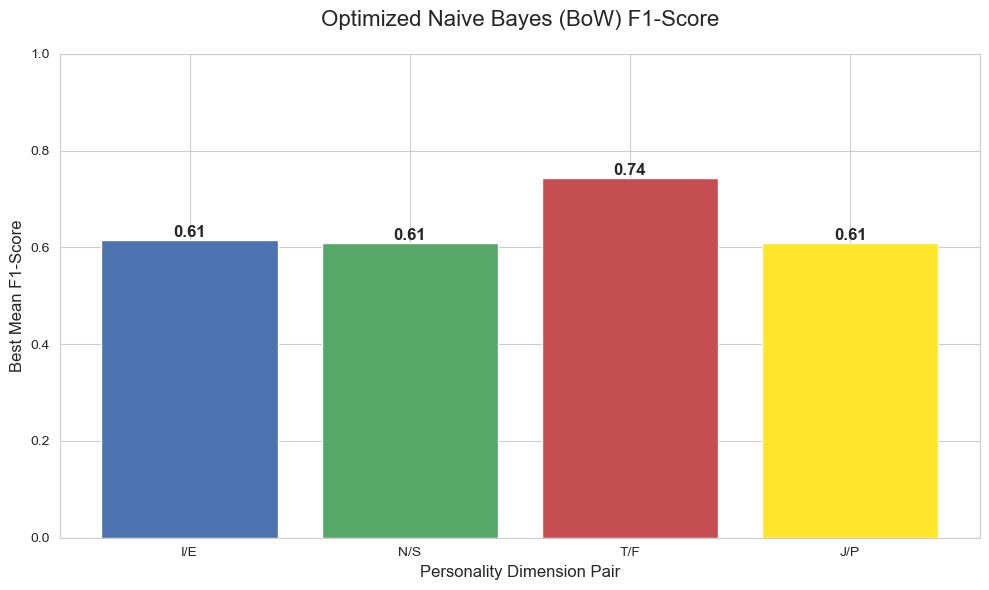


 Optimization Summary (BoW):
  I/E: Alpha=0.01, Fit Prior=True
  N/S: Alpha=1.0, Fit Prior=True
  T/F: Alpha=0.5, Fit Prior=True
  J/P: Alpha=20.0, Fit Prior=True

 Average Optimized F1-Score: 0.6439


In [22]:
print("\n Starting Naive Bayes (BoW) with Grid Search Tuning")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
best_params_log = {}

# Set up 5-fold cross-validation
# Stratified ensures each fold has the same proportion of class labels
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the Pipeline
# RandomOverSampler is now part of the CV loop (avoids data leakage)
pipeline = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', MultinomialNB())
])

# Define Hyperparameters to Tune
param_grid = {
    'classifier__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0], # Smoothing parameter (added 20.0 for BoW)
    'classifier__fit_prior': [True, False]                 # Whether to learn class priors
}

sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Tuning {trait1} vs {trait2} (BoW) ---")
    
    # Create binary labels
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro', # Optimizing for F1-Macro
        n_jobs=-1,          # Use all CPU cores
        verbose=1
    )
    
    # Run the search
    # Note: 'X' here is expected to be your Bag of Words (CountVectorizer) features
    grid_search.fit(X, y_binary)
    
    # Store best results
    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    results[f"{trait1}/{trait2}"] = best_score
    best_params_log[f"{trait1}/{trait2}"] = best_params
    
    print(f"Best F1-Score: {best_score:.4f}")
    print(f"Best Params: {best_params}")
    
    # Generate predictions on full dataset using the best model found
    y_pred_full = grid_search.predict(X)
    print(f"   Confusion Matrix (Full Data):\n{confusion_matrix(y_binary, y_pred_full)}")

# --- PLOTTING THE RESULTS ---
print("\n📊 Generating Bar Graph of Best Scores (BoW)...")
plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

plt.title('Optimized Naive Bayes (BoW) F1-Score', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Best Mean F1-Score', fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- FINAL SUMMARY ---
print("\n Optimization Summary (BoW):")
for dim, params in best_params_log.items():
    print(f"  {dim}: Alpha={params['classifier__alpha']}, Fit Prior={params['classifier__fit_prior']}")

avg_f1 = sum(results.values()) / len(results)
print(f"\n Average Optimized F1-Score: {avg_f1:.4f}")


📊 Generating BoW Results Graph...


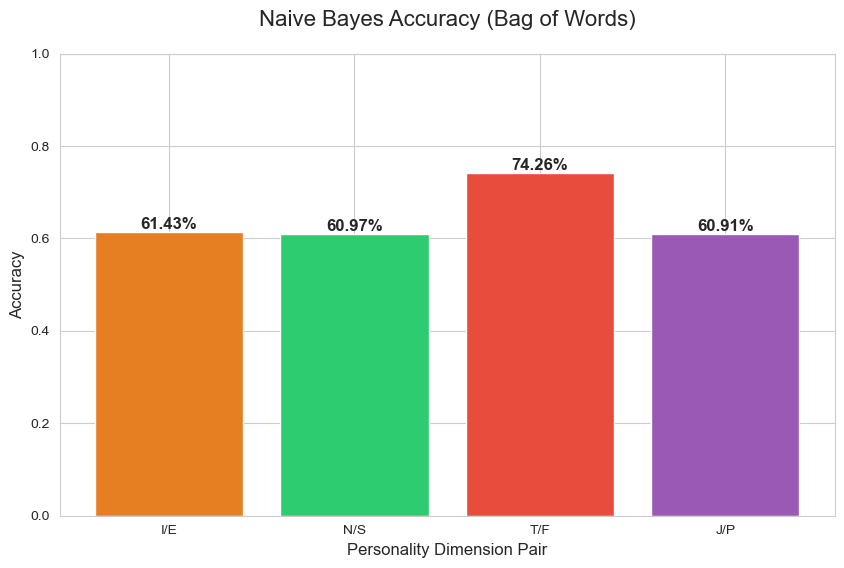

In [23]:
# --- PLOTTING THE RESULTS ---
print("\n📊 Generating BoW Results Graph...")

plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Using a slightly different color palette to distinguish from TF-IDF
bars = plt.bar(keys, values, color=['#e67e22', '#2ecc71', '#e74c3c', '#9b59b6'])

plt.title('Naive Bayes Accuracy (Bag of Words)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0) 

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

In [24]:
# --- Final Summary ---
print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
for pair, score in results.items():
    print(f"{pair}: {score:.2%}")


FINAL RESULTS
I/E: 61.43%
N/S: 60.97%
T/F: 74.26%
J/P: 60.91%
